In [5]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

df = pd.read_csv("wifi_small.csv")

df = df.apply(pd.to_numeric, errors = 'coerce')

print(df.shape)
print(df.head())
print(df.info())

/var/folders/d9/z1kygy_972vf92w9p6v6mlj80000gn/T/ipykernel_86614/2489618763.py:6: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("wifi_small.csv")


(3115401, 33)
       amp_0      amp_1      amp_2      amp_3      amp_4      amp_5  \
0  18.777386   7.824749   9.650736  18.082470  21.137028  14.382950   
1  15.140501  15.080527  14.440043  15.154455  14.831031  15.137025   
2  24.460533   8.704485  19.828470  18.977856  17.585667   9.160032   
3  14.493302  14.436395  15.991756  21.138718  20.622324  16.897657   
4   6.529867  19.694368  23.284798  20.560404  14.004681  18.223183   

       amp_6      amp_7      amp_8      amp_9  ...   phase_8   phase_9  \
0  25.523808  16.315413  16.621166  20.515250  ...  0.096695  3.002378   
1  15.464047  15.140466  15.973205  15.895749  ... -2.995179  1.245563   
2   9.585218  16.634937  15.355183  16.889008  ...  3.280194  0.339221   
3  14.978032  10.384992  14.123716  13.071758  ... -0.389476 -3.844562   
4  13.995755  15.978740  16.538630  14.494336  ...  2.828019  2.347581   

   phase_10  phase_11  phase_12  phase_13  phase_14  occupancy  movement  \
0  2.053890  0.624243 -0.676748  2.103

In [6]:
# Check missing values 
missing_values = df.isna().sum() 

if missing_values.sum() == 0:
    print('Missing Values : None')
else: 
    print('Missing values for each column:\n', missing_values[missing_values > 0])
    df.dropna()

# Check infinite values
infinite_values = np.isinf(df).sum()
if infinite_values.sum() == 0:
    print('\n Infinite Values: None')
else:
    print('\ Infinite Values for each column: ', infinite_values[infinite_values > 0])


Missing values for each column:
 amp_0             1
amp_1             1
amp_2             1
amp_3             1
amp_4             1
amp_5             1
amp_6             1
amp_7             1
amp_8             1
amp_9             1
amp_10            1
amp_11            1
amp_12            1
amp_13            1
amp_14            1
phase_0           1
phase_1           1
phase_2           1
phase_3           1
phase_4           1
phase_5           1
phase_6           1
phase_7           1
phase_8           1
phase_9           1
phase_10          1
phase_11          1
phase_12          1
phase_13          1
phase_14          1
occupancy         1
movement          1
heart_rate_bpm    1
dtype: int64


<>:15: SyntaxWarning: invalid escape sequence '\ '
<>:15: SyntaxWarning: invalid escape sequence '\ '
/var/folders/d9/z1kygy_972vf92w9p6v6mlj80000gn/T/ipykernel_86614/3173078517.py:15: SyntaxWarning: invalid escape sequence '\ '
  print('\ Infinite Values for each column: ', infinite_values[infinite_values > 0])



 Infinite Values: None


In [7]:
# Checking statistical outliers
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 *IQR
    upper_bound = Q3 + 1.5 *IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

cols_to_check = [col for col in df.columns if col not in ['occupancy','movement']]

for col in cols_to_check:
    outliers = count_outliers(df[col])
    print(f"{col.ljust(15)}: {outliers} outliers \t({(outliers/len(df))*100:.2f}%)")

amp_0          : 495645 outliers 	(15.91%)
amp_1          : 502701 outliers 	(16.14%)
amp_2          : 514130 outliers 	(16.50%)
amp_3          : 516574 outliers 	(16.58%)
amp_4          : 515367 outliers 	(16.54%)
amp_5          : 513956 outliers 	(16.50%)
amp_6          : 505542 outliers 	(16.23%)
amp_7          : 493103 outliers 	(15.83%)
amp_8          : 511325 outliers 	(16.41%)
amp_9          : 506855 outliers 	(16.27%)
amp_10         : 487724 outliers 	(15.66%)
amp_11         : 504320 outliers 	(16.19%)
amp_12         : 511737 outliers 	(16.43%)
amp_13         : 485838 outliers 	(15.59%)
amp_14         : 488441 outliers 	(15.68%)
phase_0        : 2544 outliers 	(0.08%)
phase_1        : 2778 outliers 	(0.09%)
phase_2        : 2527 outliers 	(0.08%)
phase_3        : 2681 outliers 	(0.09%)
phase_4        : 2636 outliers 	(0.08%)
phase_5        : 2600 outliers 	(0.08%)
phase_6        : 2575 outliers 	(0.08%)
phase_7        : 2674 outliers 	(0.09%)
phase_8        : 2651 outliers 	(0.

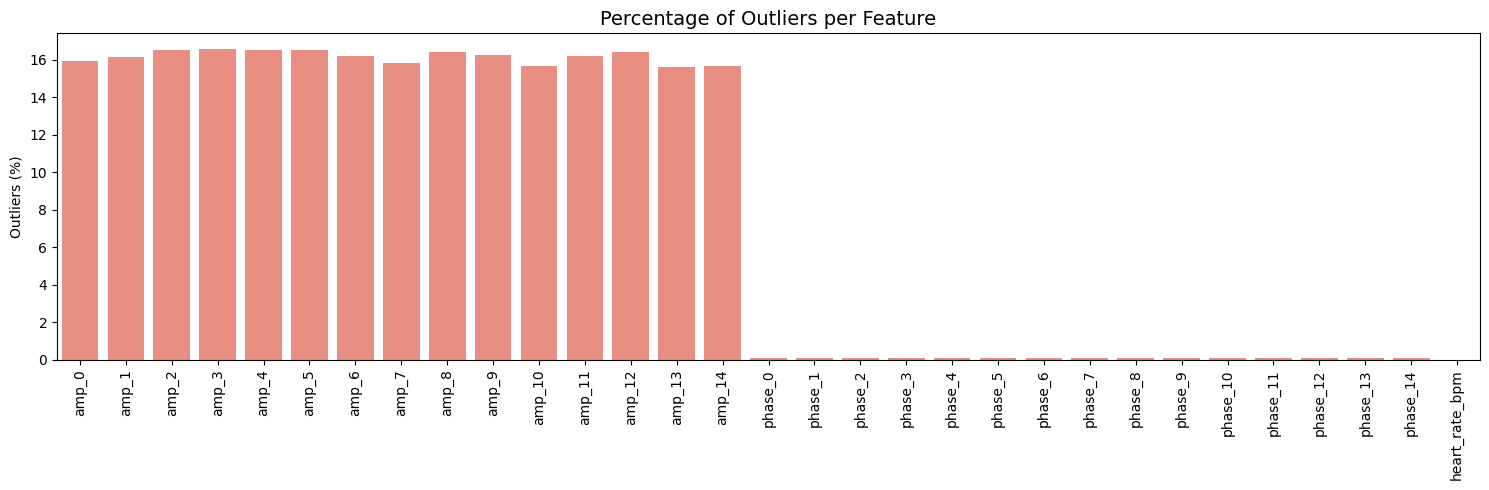

In [8]:
outlier_percentages = {}
for col in cols_to_check:
    outliers = count_outliers(df[col])
    outlier_percentages[col] = (outliers / len(df)) * 100

# Plot of the percentage of outliers per feature
plt.figure(figsize=(15, 5))
sns.barplot(x=list(outlier_percentages.keys()), y=list(outlier_percentages.values()), color='salmon')
plt.title("Percentage of Outliers per Feature", fontsize=14)
plt.ylabel("Outliers (%)")
plt.xticks(rotation=90) # Rotate labels so they don't overlap
plt.tight_layout()
plt.show()

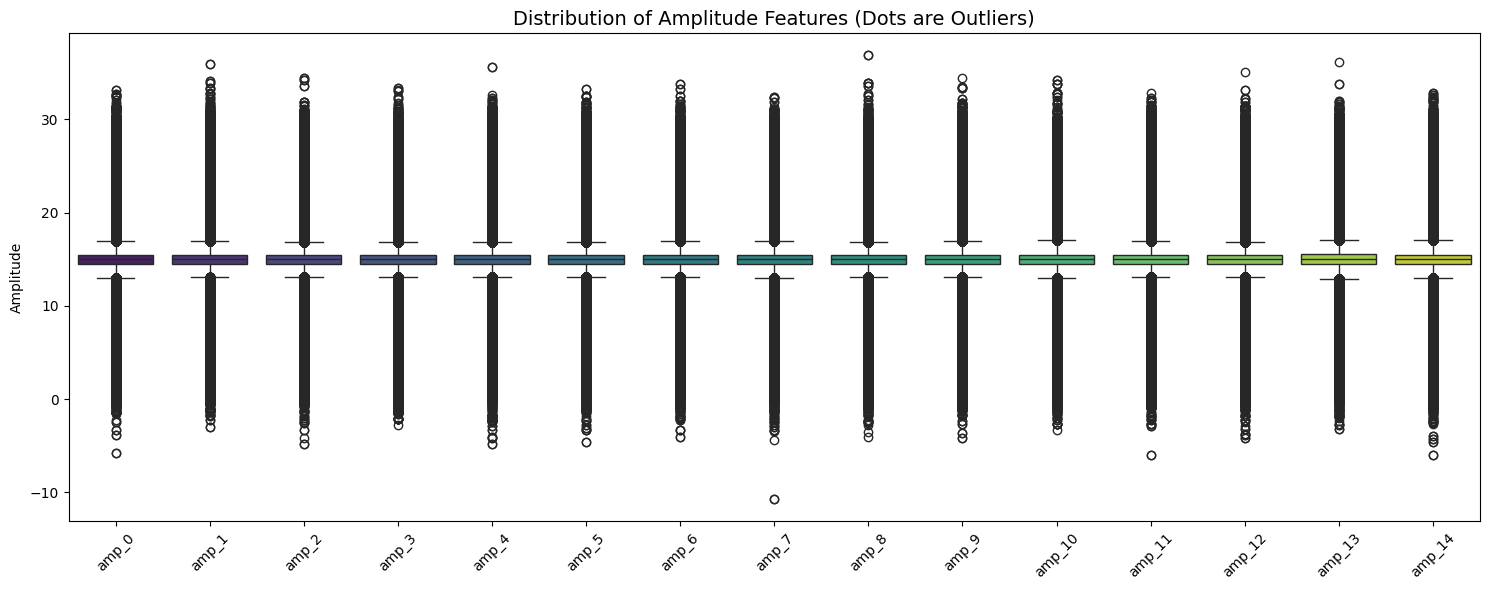

In [9]:
# Boxplot of amplitutde (amp)
amp_cols = [col for col in df.columns if col.startswith('amp_')]
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[amp_cols], palette="viridis")
plt.title("Distribution of Amplitude Features (Dots are Outliers)", fontsize=14)
plt.ylabel("Amplitude")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

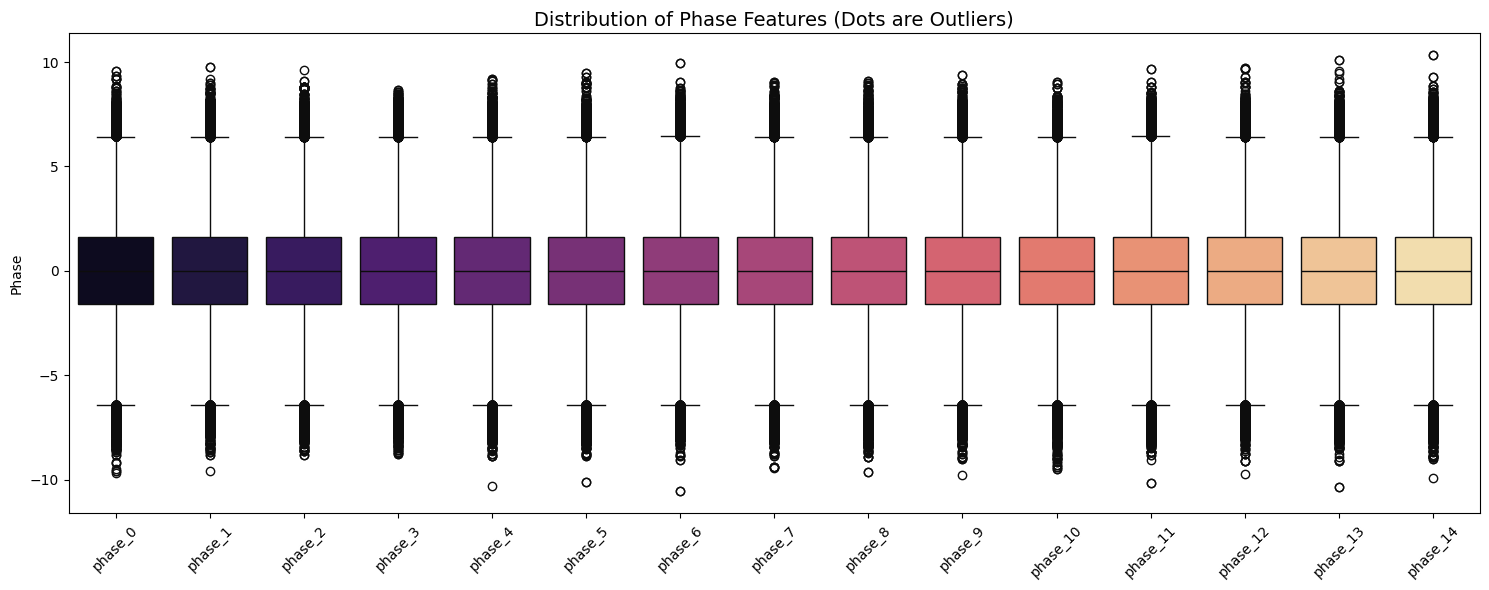

In [10]:
# Boxplot of phase
phase_cols = [col for col in df.columns if col.startswith('phase_')]
plt.figure(figsize=(15, 6))
sns.boxplot(data=df[phase_cols], palette="magma")
plt.title("Distribution of Phase Features (Dots are Outliers)", fontsize=14)
plt.ylabel("Phase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# The Golden Rule for Heart Rate Extraction:
df_valid_hr = df[
    (df['movement'] == 0) &      # They are sitting still
    (df['occupancy'] == 1) &     # There is actually a human in the room
    (df['heart_rate_bpm'] > 0)   # The sensor actually recorded a pulse
].copy()


In [19]:
print("Original Dataset Shape:", df.shape)
# --- 1. FIX CORRUPTED ROWS ---
# Force convert everything to numbers. Any weird text/headers become NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop the rows that were completely broken (where the target variable became NaN)
df = df.dropna(subset=['movement', 'occupancy'])
# --- 2. HANDLE MISSING DATA ---
# Forward-fill any missing sensor data so we don't break the timeline
df = df.ffill() 
# --- 3. NOISE SMOOTHING (FILTERING) ---
# Select only the amplitude and phase columns
features_to_smooth = [col for col in df.columns if col.startswith('amp_') or col.startswith('phase_')]
# Apply a rolling median filter with a window of 5. 
# min_periods=1 ensures the first 4 rows don't become NaN
df[features_to_smooth] = df[features_to_smooth].rolling(window=5, min_periods=1).median()
# Make sure our targets are integers (0 or 1)
print("Cleaned Dataset Shape:", df.shape)
print("Are there any missing values left?", df.isna().sum().sum() == 0)


Original Dataset Shape: (3115400, 33)


KeyboardInterrupt: 

--- 1. Dimensionality Reduction (PCA) for Movement ---


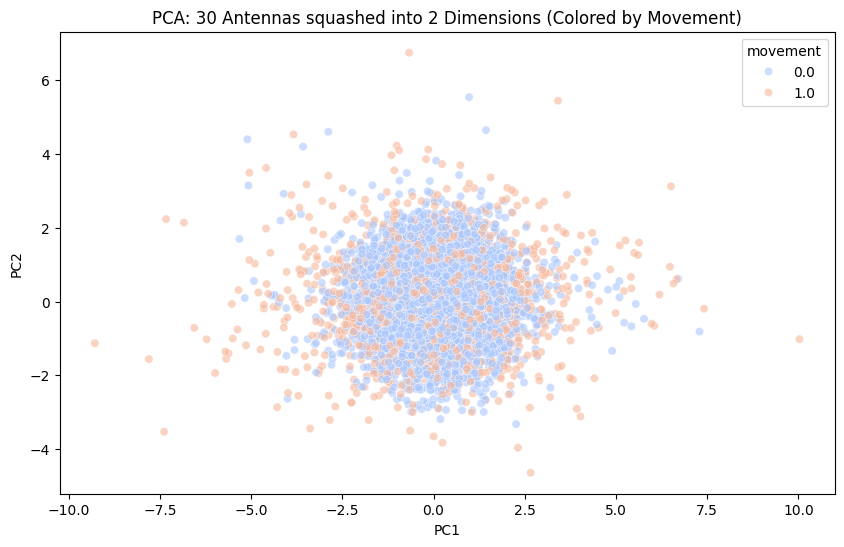

Total Variance explained by just 3 components: 11.21%


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("--- 1. Dimensionality Reduction (PCA) for Movement ---")
# We only want to shrink the signal features, not our targets!
signal_cols = [col for col in df.columns if col.startswith('amp_') or col.startswith('phase_')]
X_signals = df[signal_cols]
# Step 1: PCA requires data to be scaled first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_signals)
# Step 2: Apply PCA to shrink 30 columns down to just 3 "Super Columns"
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
# Step 3: Visualize how well these components separate the movement data
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca['movement'] = df['movement'].values
# Plotting a random sample of 10,000 points so it doesn't crash your computer
sample_pca = df_pca.sample(n=10000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_pca, x='PC1', y='PC2', hue='movement', palette='coolwarm', alpha=0.6)
plt.title("PCA: 30 Antennas squashed into 2 Dimensions (Colored by Movement)")
plt.show()
print(f"Total Variance explained by just 3 components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

--- 2. Signal Processing for Heart Rate ---
Estimated Heart Rate from Wi-Fi wave: 72.0 BPM
Actual Heart Rate recorded in dataset: 49.3 BPM


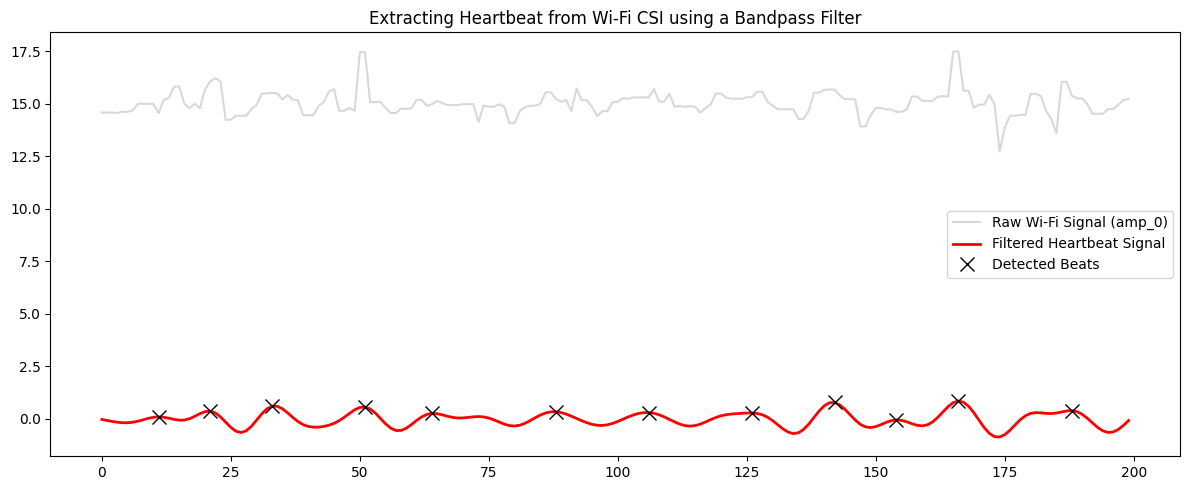

In [13]:
from scipy.signal import butter, filtfilt, find_peaks

print("--- 2. Signal Processing for Heart Rate ---")
# Step 1: Filter to ONLY rows where the person is sitting still
# Footsteps destroy heartbeat data!
df_still = df[df['movement'] == 0].copy()
# Your dataset has ~1.7M rows over 1440 mins. That's exactly 20 packets per second (20 Hz)
fs = 20.0 
# Let's grab an arbitrary 10-second slice of data to analyze (10 secs * 20 Hz = 200 rows)
# We will just look at one antenna's amplitude (amp_0)
sample_signal = df_still['amp_0'].iloc[1000:1200].values 
# Step 2: Create a Bandpass Filter
# A human heart beats between 48-120 BPM (0.8 Hz to 2.0 Hz)
lowcut = 0.8
highcut = 2.0
nyq = 0.5 * fs # Nyquist Frequency
b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
# Step 3: Apply the filter to the raw signal
filtered_signal = filtfilt(b, a, sample_signal)
# Step 4: Find the peaks (heartbeats) in the filtered signal
peaks, _ = find_peaks(filtered_signal, distance=(fs/highcut))
# Calculate estimated BPM based on the peaks we found
beats_per_second = len(peaks) / (len(sample_signal) / fs)
estimated_bpm = beats_per_second * 60
print(f"Estimated Heart Rate from Wi-Fi wave: {estimated_bpm:.1f} BPM")
print(f"Actual Heart Rate recorded in dataset: {df_still['heart_rate_bpm'].iloc[1000:1200].mean():.1f} BPM")
# Plot the raw vs filtered heartbeat signal
plt.figure(figsize=(12, 5))
plt.plot(sample_signal, label='Raw Wi-Fi Signal (amp_0)', alpha=0.3, color='gray')
plt.plot(filtered_signal, label='Filtered Heartbeat Signal', color='red', linewidth=2)
plt.plot(peaks, filtered_signal[peaks], "x", color='black', markersize=10, label='Detected Beats')
plt.title("Extracting Heartbeat from Wi-Fi CSI using a Bandpass Filter")
plt.legend()
plt.tight_layout()
plt.show()

--- 3. PCA + Bandpass Filtering on all Antennas ---
Estimated Heart Rate (Pro Method): 60.0 BPM
Actual Heart Rate recorded in dataset: 49.3 BPM


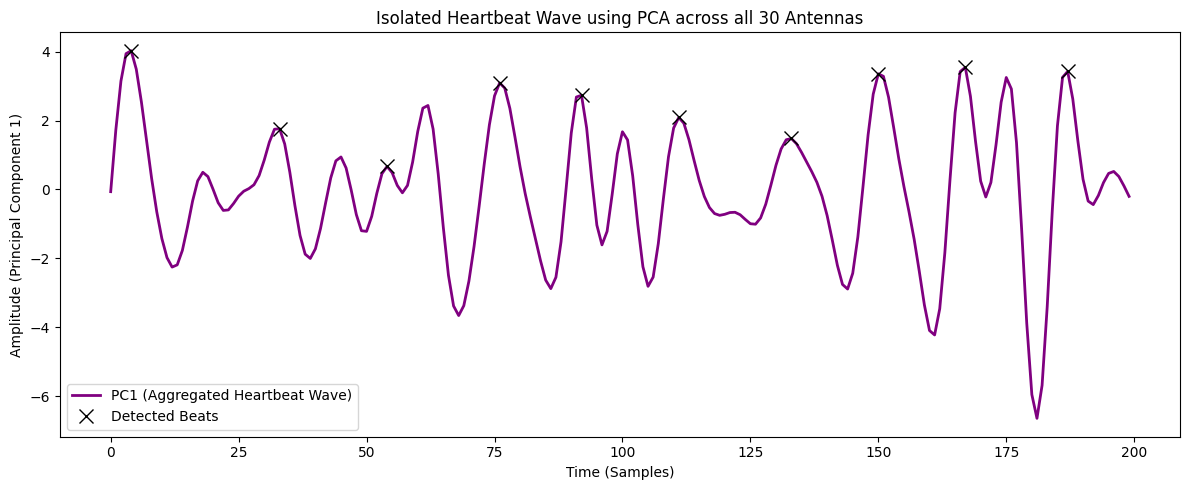

In [15]:
print("--- 3. PCA + Bandpass Filtering on all Antennas ---")
# Step 1: Isolate the still period and the signal columns
df_still = df[df['movement'] == 0].copy()
signal_cols = [col for col in df.columns if col.startswith('amp_') or col.startswith('phase_')]
# Grab the same 10-second slice (200 rows) for ALL 30 antennas
X_slice = df_still[signal_cols].iloc[1000:1200].values
actual_bpm = df_still['heart_rate_bpm'].iloc[1000:1200].mean()
# Step 2: Apply the Bandpass Filter to EVERY antenna individually
fs = 20.0 
# We widen the filter slightly (0.7 Hz to 2.5 Hz) to catch lower resting rates (like 42 BPM)
lowcut = 0.7   
highcut = 2.5  
nyq = 0.5 * fs
b, a = butter(4, [lowcut/nyq, highcut/nyq], btype='band')
# Create an empty array to hold the filtered data
X_filtered = np.zeros_like(X_slice)
# Loop through all 30 columns and filter them
for i in range(X_slice.shape[1]):
    X_filtered[:, i] = filtfilt(b, a, X_slice[:, i])
# Step 3: Scale the filtered data and apply PCA
# We want to extract the single most dominant synchronized wave among all 30 filtered antennas
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)
pca = PCA(n_components=1)
# PC1 now contains the ultimate, aggregated heartbeat signal!
pc1_signal = pca.fit_transform(X_filtered_scaled).flatten()
# Step 4: Find the peaks in our new Super-Signal
# We use distance to ensure we don't count weird double-peaks within a single heartbeat
peaks, _ = find_peaks(pc1_signal, distance=16)
beats_per_second = len(peaks) / (len(pc1_signal) / fs)
estimated_bpm = beats_per_second * 60
print(f"Estimated Heart Rate (Pro Method): {estimated_bpm:.1f} BPM")
print(f"Actual Heart Rate recorded in dataset: {actual_bpm:.1f} BPM")
# Plot the beautiful, isolated heartbeat wave
plt.figure(figsize=(12, 5))
plt.plot(pc1_signal, label='PC1 (Aggregated Heartbeat Wave)', color='purple', linewidth=2)
plt.plot(peaks, pc1_signal[peaks], "x", color='black', markersize=10, label='Detected Beats')
plt.title("Isolated Heartbeat Wave using PCA across all 30 Antennas")
plt.xlabel("Time (Samples)")
plt.ylabel("Amplitude (Principal Component 1)")
plt.legend()
plt.tight_layout()
plt.show()